### **Modeling — predicting the sale price on the GPU**

Everything runs on the GPU: `cudf` holds the frames, `cuml` supplies the split, the
metrics and the linear models, and XGBoost trains with `device="cuda"`. Nothing is
copied back to host memory except the small result tables.

- **data** — `SELL_REAL_ESTATE_FOR_MODELING.parquet`, 533,399 sale listings, 38 columns
- **target** — `log1p(price)`. Prices span four orders of magnitude, so on the raw
  scale a handful of listings own the loss
- **split** — 70 / 30 with `random_state=42`, the same split for every model here
- **read the errors in SAR** — every metric undoes the `log1p` (and, for land, the
  per-square-metre divisor) before it is reported

In [1]:
import random
import threading
import time
from collections.abc import Callable, Iterator
from contextlib import contextmanager
from dataclasses import dataclass

import cudf
import cupy as cp
import cuml.metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import pynvml
import seaborn as sns
import xgboost as xgb
from cuml.linear_model import Lasso, LinearRegression, Ridge
from cuml.model_selection import train_test_split
from cuml.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, KFold
from xgboost import XGBRegressor

In [2]:
pd.set_option("display.max_columns", 200)   
pd.set_option("display.width", 2000)        
pd.set_option("display.max_colwidth", 100)

#### **Measuring what the GPU actually does**

Every model below is trained inside the same instrumentation, so the resource numbers
in the final table come from one measurement path rather than from four.

- **utilisation** — `nvidia-ml-py` is polled on a background thread every 50 ms for the
  length of each block, so the card is read while the work runs rather than after it
  has finished and gone idle. `util_samples` in the final table says how many readings
  a number rests on; a fit that finishes in milliseconds gets one or two, and the
  driver's counter covers a window that may reach back before the block started
- **memory** — device-wide peak during the block, and the rise above the reading taken
  just before it, which is the part the block itself is responsible for
- **execution time** — preparation, hyper-parameter search and final refit are timed
  separately, because they are three different costs
- **speed** — training rows per second for the final refit, and prediction rows per
  second over the test split, averaged across repeated passes after a warm-up

The device is synchronised before each clock stops. cuDF, cuPy and cuML queue their
work asynchronously, so a timer that does not synchronise measures how fast Python
launched the kernels, not how long the GPU took to run them.

In [3]:
pynvml.nvmlInit()
GPU_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
SAMPLE_INTERVAL_S = 0.05
PREDICT_REPEATS = 20
# Below this many readings a utilisation mean is one stale counter, not an average.
SAMPLED_MIN = 20


def gpu_stats() -> dict[str, float]:
    """Instantaneous GPU utilisation and memory use."""
    util = pynvml.nvmlDeviceGetUtilizationRates(GPU_HANDLE)
    mem = pynvml.nvmlDeviceGetMemoryInfo(GPU_HANDLE)
    return {"gpu_util_pct": float(util.gpu),
            "mem_used_gb": mem.used / 1024**3,
            "mem_total_gb": mem.total / 1024**3}


@contextmanager
def timed(label: str, sink: dict[str, dict[str, float]]) -> Iterator[None]:
    """Time a block while sampling GPU utilisation and memory in the background.

    A single reading taken after the block would land once the GPU is already idle,
    so utilisation is polled on a worker thread for the block's duration. The device
    is synchronised before the clock stops: cuDF, cuPy and cuML queue their work
    asynchronously, and without the barrier the number is the kernel launch cost.
    """
    samples: list[dict[str, float]] = []
    stop = threading.Event()
    baseline = gpu_stats()

    def poll() -> None:
        while not stop.is_set():
            samples.append(gpu_stats())
            stop.wait(SAMPLE_INTERVAL_S)

    worker = threading.Thread(target=poll, daemon=True)
    worker.start()
    t0 = time.perf_counter()
    try:
        yield
    finally:
        cp.cuda.runtime.deviceSynchronize()
        elapsed = time.perf_counter() - t0
        stop.set()
        worker.join()
        utils = [s["gpu_util_pct"] for s in samples] or [0.0]
        mems = [s["mem_used_gb"] for s in samples] or [baseline["mem_used_gb"]]
        stats = {"seconds": elapsed,
                 "gpu_util_mean_pct": sum(utils) / len(utils),
                 "gpu_util_max_pct": max(utils),
                 "mem_baseline_gb": baseline["mem_used_gb"],
                 "mem_peak_gb": max(mems),
                 "mem_delta_gb": max(mems) - baseline["mem_used_gb"],
                 "mem_total_gb": baseline["mem_total_gb"],
                 "samples": float(len(samples))}
        sink[label] = stats
        print(f"  [{label}] {elapsed:8.2f}s  gpu avg={stats['gpu_util_mean_pct']:5.1f}% "
              f"max={stats['gpu_util_max_pct']:3.0f}%  mem peak={stats['mem_peak_gb']:.2f}"
              f"/{stats['mem_total_gb']:.1f} GB (+{stats['mem_delta_gb']:.2f})  "
              f"n={len(samples)}", flush=True)


def inference_speed(predict_fn: Callable[[object], object], X: object, label: str,
                    sink: dict[str, dict[str, float]], repeats: int) -> None:
    """Prediction throughput for any GPU model, averaged over repeated passes.

    The warm-up call absorbs the first-call allocation and any lazy compilation, and
    the device is synchronised on both sides of the clock. A linear model scores the
    test split in under a millisecond, which is mostly timer noise on a single pass,
    so the pass is repeated and the mean reported.
    """
    predict_fn(X[:1000])
    cp.cuda.runtime.deviceSynchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        predict_fn(X)
    cp.cuda.runtime.deviceSynchronize()
    elapsed = (time.perf_counter() - t0) / repeats
    sink[label] = {"seconds": elapsed, "rows": float(len(X)),
                   "rows_per_s": len(X) / elapsed, "repeats": float(repeats)}
    print(f"  [{label}] {elapsed*1000:.2f} ms for {len(X):,} rows "
          f"({len(X) / elapsed:,.0f} rows/s, mean of {repeats})", flush=True)


def train_throughput(rows: int, seconds: float) -> float:
    """Training rows per second for a fit that saw `rows` rows."""
    return rows / seconds


timings: dict[str, dict[str, float]] = {}
print(pynvml.nvmlDeviceGetName(GPU_HANDLE), gpu_stats())

NVIDIA GeForce RTX 3090 {'gpu_util_pct': 10.0, 'mem_used_gb': 1.79241943359375, 'mem_total_gb': 24.0}


In [4]:
df = cudf.read_parquet('../data/SELL_REAL_ESTATE_FOR_MODELING.parquet')
df.sample()

,price,bedrooms,living_rooms,bathrooms,area_m2,street_width_m,is_furnished,city,district,has_ac,has_parking,has_pool,has_kitchen,has_driver_room,has_basement,has_garden,has_two_entrances,is_corner,near_masjid,is_investment,is_negotiable,is_urgent,near_park,has_yard,bedrooms_missing,living_rooms_missing,bathrooms_missing,furnished_missing,street_width_missing,type_apartment,type_building,type_esterahah,type_farm,type_floor,type_house,type_land,type_store,type_villa
506368,350000,0.0,0.0,0.0,500.0,15.0,0,الرياض,حي عريض,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,1,0,0


#### **First attempt — one model over every estate type**

In [5]:
DROP_TEXT = []

d = df.copy()

with timed("all_wide:prep", timings):
    y = cudf.Series(cp.log1p(d["price"].to_cupy()), index=d.index)
    X = d.drop(columns=["price"] + DROP_TEXT)

    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category").cat.codes.astype("int32")

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    y_tr, y_te = y_tr.to_numpy(), y_te.to_numpy()

print(X.dtypes.value_counts())
assert "price" not in X.columns
print(X_tr.shape, X_te.shape)

  [all_wide:prep]     0.13s  gpu avg= 29.0% max= 29%  mem peak=2.28/24.0 GB (+0.08)  n=3


int8       30
float64     5
int32       2
Name: count, dtype: int64
(373379, 37) (160020, 37)


In [6]:
params = {
    "n_estimators":     [100, 300, 500, 700, 1000],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05],
    "max_depth":        [6, 8, 10, 12],
    "min_child_weight": [1, 5, 10, 20],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda":       [1, 5, 20],
}

XGB_FIXED = {"tree_method": "hist", "device": "cuda", "enable_categorical": True,
             "max_cat_to_onehot": 1, "random_state": 42}

# refit=False so the winner's fit is measured on its own clock instead of being
# folded into the search, which is what the timing table needs them separated for.
search = RandomizedSearchCV(XGBRegressor(**XGB_FIXED), params, n_iter=50,
                            cv=KFold(3, shuffle=True, random_state=42),
                            scoring="neg_root_mean_squared_error",
                            n_jobs=1, verbose=1, random_state=42, refit=False)

with timed("all_wide:tune", timings):
    search.fit(X_tr, y_tr)

model_all_wide = XGBRegressor(**XGB_FIXED, **search.best_params_)
with timed("all_wide:fit", timings):
    model_all_wide.fit(X_tr, y_tr)

inference_speed(model_all_wide.predict, X_te, "all_wide:predict", timings, PREDICT_REPEATS)

print(f"CV RMSE (log): {-search.best_score_:.4f}")
print(search.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


  [all_wide:tune]   330.68s  gpu avg= 84.3% max= 94%  mem peak=3.02/24.0 GB (+0.70)  n=6595


  [all_wide:fit]     7.15s  gpu avg= 90.8% max= 92%  mem peak=2.78/24.0 GB (+0.15)  n=143


  [all_wide:predict] 22.53 ms for 160,020 rows (7,103,669 rows/s, mean of 20)


CV RMSE (log): 0.5985
{'subsample': 0.8, 'reg_lambda': 20, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [7]:
def scores(X, y):
    p = cp.asarray(model_all_wide.predict(X))
    y = cp.asarray(y)
    true, pred = cp.expm1(y), cp.expm1(p)
    return {"R2": cuml.metrics.r2_score(y, p),
            "RMSE_log": float(cuml.metrics.mean_squared_error(y, p) ** 0.5),
            "MAE_SAR": cuml.metrics.mean_absolute_error(true, pred),
            "MedAPE%": float(cp.median(cp.abs(pred - true) / true) * 100)}

pd.DataFrame([scores(X_tr, y_tr), scores(X_te, y_te)], index=["train", "test"]).round(3)

,R2,RMSE_log,MAE_SAR,MedAPE%
train,0.835,0.493,1487498.654,10.010
test,0.757,0.601,1853984.083,10.949


In [8]:
for i in ['type_apartment','type_building','type_esterahah','type_farm','type_floor','type_house','type_land','type_store','type_villa']:
    print(df[i].value_counts())

type_apartment
0    436263
1     97136
Name: count, dtype: int64
type_building
0    506305
1     27094
Name: count, dtype: int64
type_esterahah
0    528155
1      5244
Name: count, dtype: int64
type_farm
0    532690
1       709
Name: count, dtype: int64
type_floor
0    533145
1       254
Name: count, dtype: int64
type_house
0    529764
1      3635
Name: count, dtype: int64
type_land
0    320181
1    213218
Name: count, dtype: int64
type_store
0    532042
1      1357
Name: count, dtype: int64
type_villa
0    348647
1    184752
Name: count, dtype: int64


In [9]:
tcols = [c for c in d.columns if c.startswith("type_")]

print(d[tcols].sum(axis=1).value_counts())

1    533399
Name: count, dtype: int64


In [10]:
print(d.nlargest(10, "price")[["price", "area_m2", "type_land"]])
print(d.nsmallest(10, "price")[["price", "area_m2", "type_land"]])

              price     area_m2  type_land
19490   10000000000  10000000.0          1
361802   9021000000   9300000.0          1
302959   8955592000   2238898.0          1
124566   8000000000   2150000.0          1
216121   7955000000   2150000.0          1
473294   7735781888     17185.0          1
90641    7500000000  10000000.0          1
332498   7500000000   1500000.0          1
445352   7500000000  10000000.0          1
99311    7371230000   2948490.0          1
        price  area_m2  type_land
526270      0    259.0          1
203690      1    300.0          0
204609      1    500.0          0
238177      1   2549.0          0
266567      1    450.0          0
305835      1    230.0          0
308005      1    300.0          0
310200      1   2500.0          0
314184      1   1100.0          0
328881      1    300.0          0


#### **Now i am try to increase the accuracy and decrease error by creating 2 separate models , one for lands and the other contains all the other estates**
- **i did it because lands effects on prices and its around 40% of the entire dataset**
- **for lands the prediction will be on price per squared meter**
- **for other estates the target will be regular price**

In [11]:
is_land = d["type_land"] == 1

d_built = d[~is_land]
d_built = d_built[
    (d_built.price >= 50_000) &
    (d_built.price <= 50_000_000)
]

d_land = d[is_land]
d_land = d_land[
    (d_land.price >= 1_000) &
    (d_land.area_m2 > 0)
]

ppm = d_land.price / d_land.area_m2

d_land = d_land[
    (ppm >= 10) &
    (ppm <= 20_000)
]

print(f"built: {len(d_built):,}   land: {len(d_land):,}")

built: 319,282   land: 210,149


In [12]:
PARAMS = {
    "n_estimators":     [100, 300, 500, 700, 1000],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05],
    "max_depth":        [5 , 6, 8, 10, 12],
    "min_child_weight": [1, 5, 10, 20],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda":       [1, 5, 20],
}

def prep(d, drop=(), divisor=None):
    """divisor: column name to divide price by (e.g. 'area_m2' for land)."""
    target = d["price"] / d[divisor] if divisor else d["price"]
    y = cudf.Series(cp.log1p(target.to_cupy()), index=d.index)
    X = d.drop(columns=["price", *drop])

    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category").cat.codes.astype("int32")

    scale = d[divisor] if divisor else None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    s_tr = cp.asarray(scale.loc[X_tr.index].to_cupy()) if divisor else 1.0
    s_te = cp.asarray(scale.loc[X_te.index].to_cupy()) if divisor else 1.0
    print(X_tr.shape, X_te.shape)
    return X_tr, X_te, y_tr.to_numpy(), y_te.to_numpy(), s_tr, s_te


def fit(X_tr, y_tr, name, n_iter):
    """Random search then a separately timed refit of the winner."""
    s = RandomizedSearchCV(XGBRegressor(**XGB_FIXED), PARAMS, n_iter=n_iter,
                           cv=KFold(3, shuffle=True, random_state=42),
                           scoring="neg_root_mean_squared_error",
                           n_jobs=1, verbose=1, random_state=42, refit=False)
    with timed(f"{name}:tune", timings):
        s.fit(X_tr, y_tr)

    best = XGBRegressor(**XGB_FIXED, **s.best_params_)
    with timed(f"{name}:fit", timings):
        best.fit(X_tr, y_tr)

    print(f"CV RMSE (log): {-s.best_score_:.4f}\n{s.best_params_}")
    return best


def report(model, sets, name):
    """sets: {'train': (X, y, scale), 'test': (X, y, scale)}"""
    rows = {}
    for split, (X, y, scale) in sets.items():
        p = cp.asarray(model.predict(X)); y = cp.asarray(y)
        true, pred = cp.expm1(y) * scale, cp.expm1(p) * scale
        ape = cp.abs(pred - true) / true
        rows[split] = {"R2_log":     cuml.metrics.r2_score(y, p),
                       "RMSE_log":   float(cuml.metrics.mean_squared_error(y, p) ** 0.5),
                       "MAE_SAR":    float(cp.mean(cp.abs(pred - true))),
                       "MedAPE%":    float(cp.median(ape) * 100),
                       "within_10%": float((ape <= 0.10).mean() * 100),
                       "within_20%": float((ape <= 0.20).mean() * 100)}
    print(f"\n=== {name} ===")
    return pd.DataFrame(rows).T.round(3)

##### **land target**

In [13]:
tcols = [c for c in d_land.columns if c.startswith("type_")]

with timed("land_wide:prep", timings):
    Xl_tr, Xl_te, yl_tr, yl_te, sl_tr, sl_te = prep(d_land, drop=tcols, divisor="area_m2")

model_land = fit(Xl_tr, yl_tr, "land_wide", n_iter=50)
inference_speed(model_land.predict, Xl_te, "land_wide:predict", timings, PREDICT_REPEATS)

report(model_land, {"train": (Xl_tr, yl_tr, sl_tr),
                    "test":  (Xl_te, yl_te, sl_te)}, "LAND")

(147104, 28) (63045, 28)
  [land_wide:prep]     0.03s  gpu avg= 59.0% max= 59%  mem peak=2.61/24.0 GB (+0.00)  n=1


Fitting 3 folds for each of 50 candidates, totalling 150 fits


  [land_wide:tune]   181.37s  gpu avg= 79.4% max= 92%  mem peak=2.89/24.0 GB (+0.25)  n=3617


  [land_wide:fit]     8.49s  gpu avg= 87.7% max= 91%  mem peak=2.56/24.0 GB (+0.10)  n=170


CV RMSE (log): 0.4079
{'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


  [land_wide:predict] 17.52 ms for 63,045 rows (3,597,468 rows/s, mean of 20)



=== LAND ===


,R2_log,RMSE_log,MAE_SAR,MedAPE%,within_10%,within_20%
train,0.947,0.258,1067621.003,8.921,54.046,77.443
test,0.875,0.397,2792818.213,11.219,46.246,68.305


##### **Building target**

In [14]:
with timed("built_wide:prep", timings):
    Xb_tr, Xb_te, yb_tr, yb_te, sb_tr, sb_te = prep(d_built)

model_built = fit(Xb_tr, yb_tr, "built_wide", n_iter=50)
inference_speed(model_built.predict, Xb_te, "built_wide:predict", timings, PREDICT_REPEATS)

report(model_built, {"train": (Xb_tr, yb_tr, sb_tr),
                     "test":  (Xb_te, yb_te, sb_te)}, "BUILT")

(223497, 37) (95785, 37)
  [built_wide:prep]     0.03s  gpu avg=  0.0% max=  0%  mem peak=2.53/24.0 GB (+0.00)  n=1


Fitting 3 folds for each of 50 candidates, totalling 150 fits


  [built_wide:tune]   239.93s  gpu avg= 81.0% max= 92%  mem peak=3.09/24.0 GB (+0.53)  n=4785


  [built_wide:fit]    11.45s  gpu avg= 90.6% max= 92%  mem peak=2.80/24.0 GB (+0.11)  n=229


CV RMSE (log): 0.2835
{'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


  [built_wide:predict] 18.14 ms for 95,785 rows (5,279,637 rows/s, mean of 20)



=== BUILT ===


,R2_log,RMSE_log,MAE_SAR,MedAPE%,within_10%,within_20%
train,0.961,0.163,217454.473,6.248,67.764,89.087
test,0.887,0.278,367644.886,8.400,56.408,79.584


##### **checking multicollinearity and permutation importance**

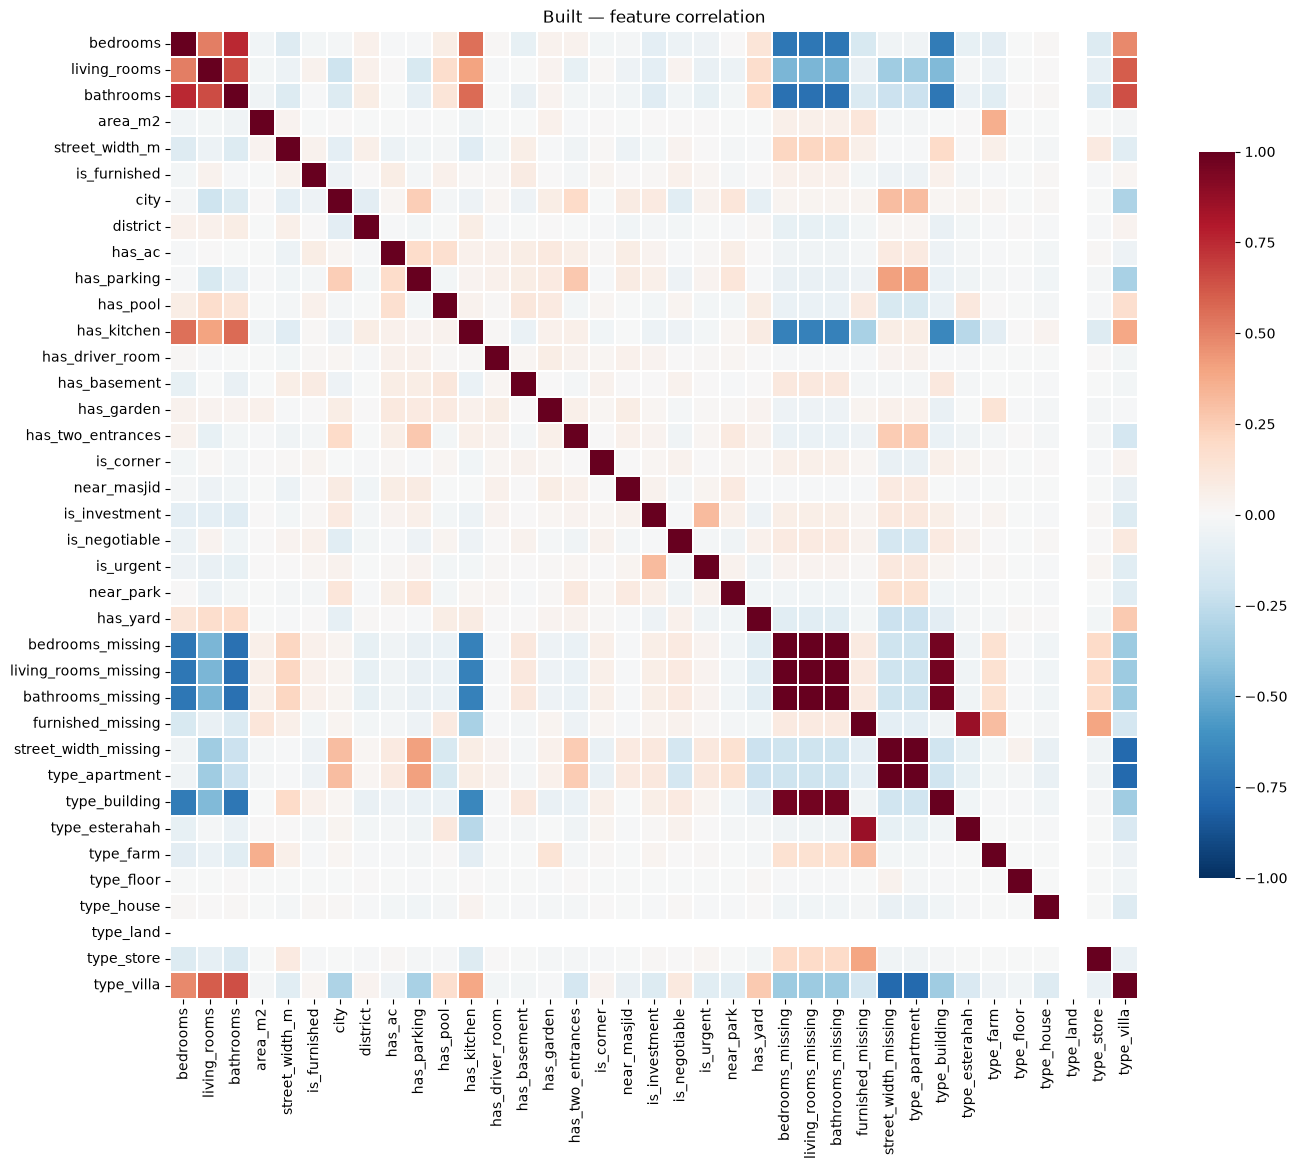

In [15]:
corr = Xb_tr.corr().to_pandas()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.3, cbar_kws={"shrink": .7})
plt.title("Built — feature correlation")
plt.tight_layout()

In [16]:
c = corr.where(~np.eye(len(corr), dtype=bool))
pairs = c.stack().abs().sort_values(ascending=False)
print(pairs[pairs > 0.7].drop_duplicates().head(20))

bedrooms_missing      living_rooms_missing    1.000000
street_width_missing  type_apartment          0.998151
type_apartment        street_width_missing    0.998151
living_rooms_missing  type_building           0.964620
furnished_missing     type_esterahah          0.860207
street_width_missing  type_villa              0.775594
type_villa            type_apartment          0.774160
type_apartment        type_villa              0.774160
bathrooms             bedrooms                0.753486
                      bedrooms_missing        0.746503
bedrooms_missing      bathrooms               0.746503
bedrooms              living_rooms_missing    0.722544
bathrooms             type_building           0.720091
type_building         bathrooms               0.720091
dtype: float64


/home/super/Desktop/Saudi_REAL_ESTATE_PROJECT/.venv/lib/python3.13/site-packages/xgboost/core.py:569: UserWarning: [04:14:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


                 feature  importance       std
3                area_m2    0.281660  0.001063
6                   city    0.217824  0.001229
7               district    0.195099  0.000551
27  street_width_missing    0.073198  0.001137
29         type_building    0.035892  0.000454
36            type_villa    0.023026  0.000162
0               bedrooms    0.020771  0.000325
4         street_width_m    0.019373  0.000635
28        type_apartment    0.019118  0.000462
2              bathrooms    0.014227  0.000286
23      bedrooms_missing    0.007510  0.000175
10              has_pool    0.007424  0.000531
1           living_rooms    0.006310  0.000189
26     furnished_missing    0.005578  0.000235
8                 has_ac    0.004632  0.000274
22              has_yard    0.003521  0.000123
35            type_store    0.003484  0.000016
9            has_parking    0.003074  0.000120
5           is_furnished    0.003046  0.000119
13          has_basement    0.002464  0.000068


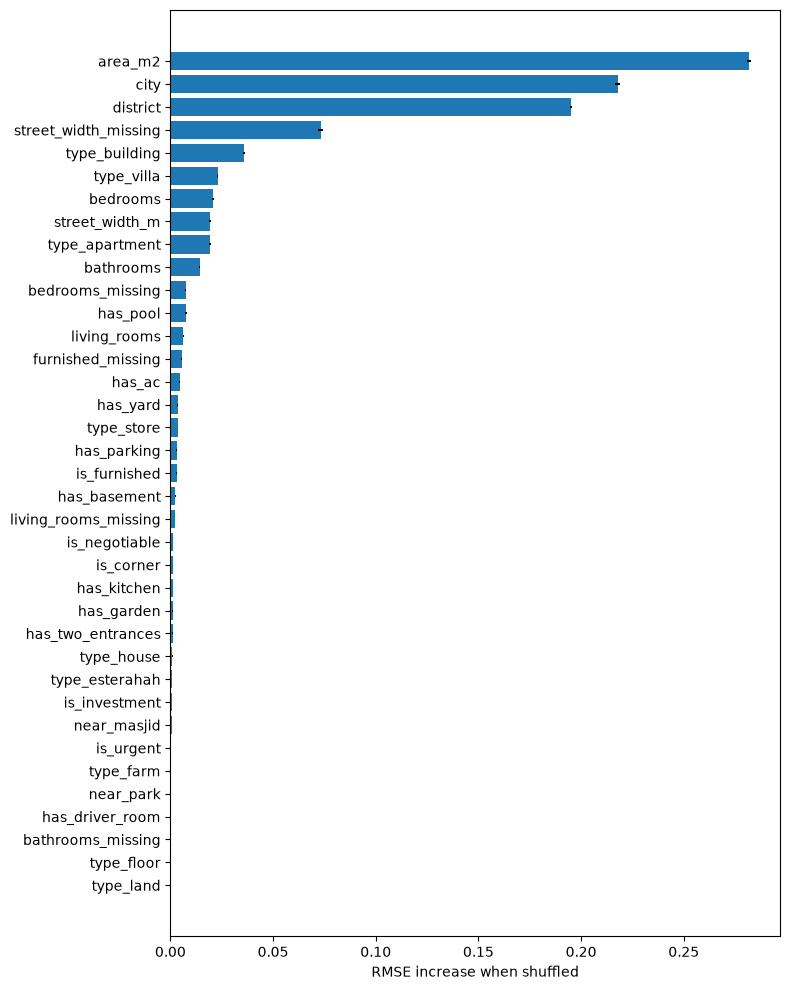

In [17]:
Xb_te_pd = Xb_te.to_pandas()

perm = permutation_importance(model_built, Xb_te_pd, yb_te,
                              n_repeats=5, random_state=42,
                              scoring="neg_root_mean_squared_error", n_jobs=1)

imp = pd.DataFrame({"feature": Xb_te_pd.columns,
                    "importance": perm.importances_mean,
                    "std": perm.importances_std}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(imp.feature[::-1], imp.importance[::-1], xerr=imp["std"][::-1])
plt.xlabel("RMSE increase when shuffled")
plt.tight_layout()
print(imp.head(20))

living_rooms  bathrooms       0.846210
bedrooms      bathrooms       0.796627
              living_rooms    0.703491
living_rooms  bedrooms        0.703491
dtype: float64


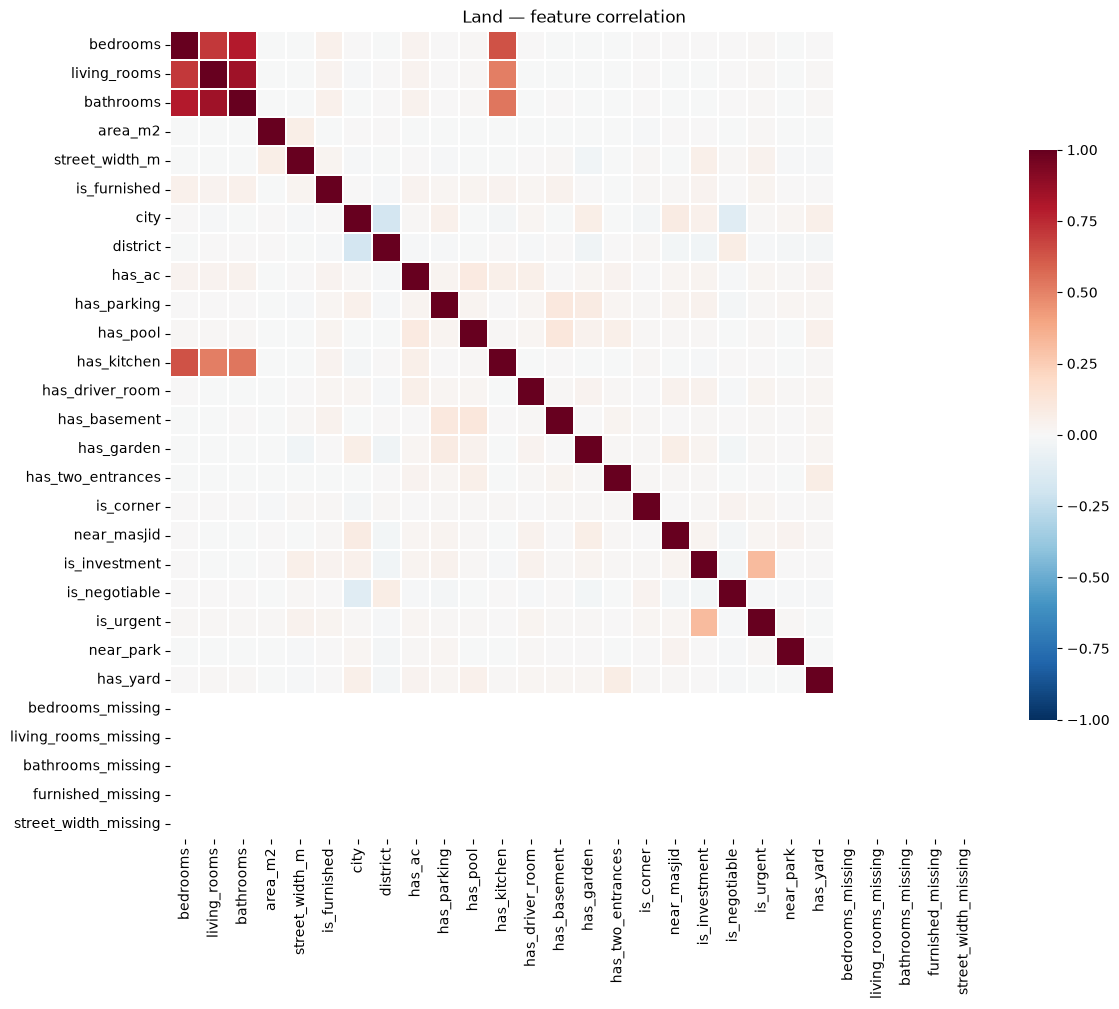

In [18]:
corr_l = Xl_tr.corr().to_pandas()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_l, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.3, cbar_kws={"shrink": .7})
plt.title("Land — feature correlation")
plt.tight_layout()

c = corr_l.where(~np.eye(len(corr_l), dtype=bool))
pairs_l = c.stack().abs().sort_values(ascending=False)
print(pairs_l[pairs_l > 0.7].drop_duplicates().head(20))

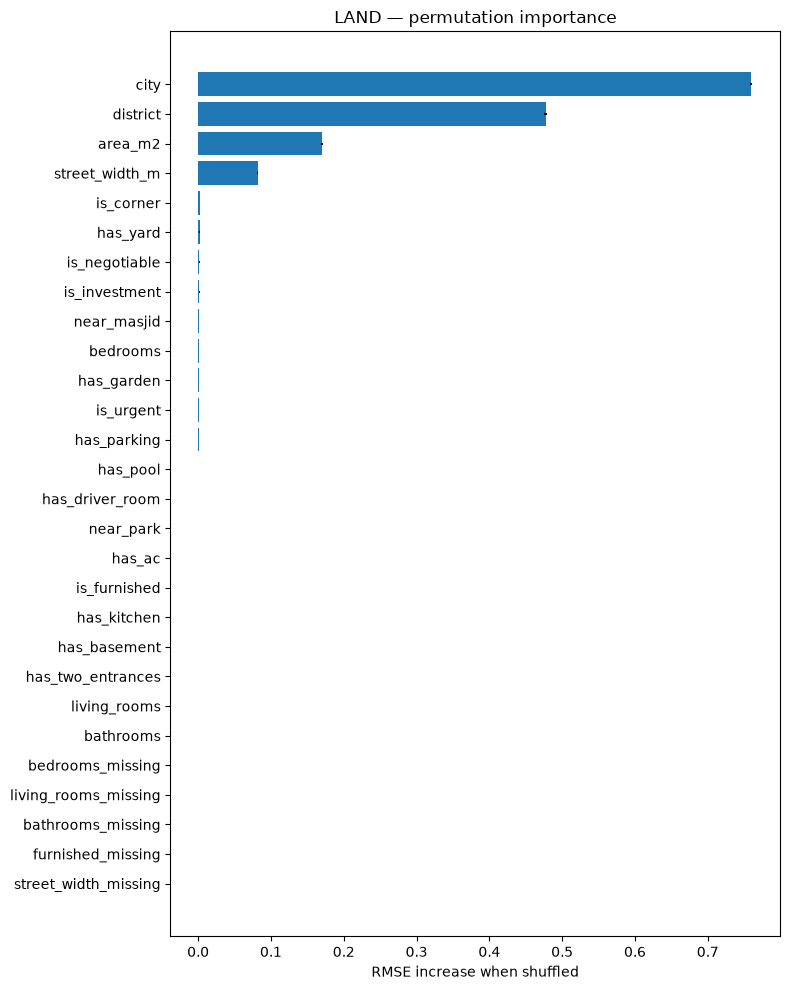

            feature  importance       std
6              city    0.759470  0.001653
7          district    0.477642  0.001932
3           area_m2    0.169920  0.001457
4    street_width_m    0.081871  0.001035
16        is_corner    0.002820  0.000212
22         has_yard    0.001926  0.000081
19    is_negotiable    0.001869  0.000257
18    is_investment    0.001790  0.000140
17      near_masjid    0.001552  0.000061
0          bedrooms    0.001163  0.000067
14       has_garden    0.001151  0.000166
20        is_urgent    0.001064  0.000154
9       has_parking    0.000874  0.000206
10         has_pool    0.000285  0.000018
12  has_driver_room    0.000252  0.000043
21        near_park    0.000192  0.000031
8            has_ac    0.000188  0.000042
5      is_furnished    0.000182  0.000018
11      has_kitchen    0.000156  0.000027
13     has_basement    0.000086  0.000038


In [19]:
Xl_te_pd = Xl_te.to_pandas()

perm_land = permutation_importance(model_land, Xl_te_pd, cp.asnumpy(yl_te),
                                   n_repeats=5, random_state=42,
                                   scoring="neg_root_mean_squared_error", n_jobs=1)

imp_land = pd.DataFrame({"feature": Xl_te_pd.columns,
                         "importance": perm_land.importances_mean,
                         "std": perm_land.importances_std}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(imp_land.feature[::-1], imp_land.importance[::-1], xerr=imp_land["std"][::-1])
plt.xlabel("RMSE increase when shuffled")
plt.title("LAND — permutation importance")
plt.tight_layout()
plt.show()

print(imp_land.head(20))

##### **second experiment for XGBoostRegressor — a regularised grid, searched natively**

The first experiment searched a grid whose cheapest corner was also its least
regularised one, and the search went there: **depth 12, `min_child_weight` 1,
`reg_lambda` 1** on both per-type targets. That is a model with room to memorise, and
it used it — 1.41M leaves on built property and a train/test `R2_log` gap of 0.074.

What changes here:

- **the grid cannot reach the memorising corner** — depth at most 8, at least 10 rows
  behind every leaf, `reg_lambda` starting at 5, and both sampling rates below 1
- **rounds are searched, not discovered** — `n_estimators` is sampled like every other
  hyper-parameter and each candidate trains for exactly that many rounds
- **each fold is scored once**, after training ends, so nothing about the fit was
  decided by looking at the fold that grades it
- **the search runs on the native booster** — `xgb.train` over a `QuantileDMatrix`
  rather than the sklearn wrapper, with the categorical columns left as categories so
  XGBoost splits on them natively instead of treating the codes as numbers
- **the train/test gap is reported** in the comparison table, so overfitting is a
  number in the output rather than something to take on trust

The budget also differs — 5 candidates here against 50 above — so the two searches
cannot be compared on wall time. The refits can, and are, in the final table.

In [20]:
# Deliberately narrower than PARAMS above. That grid let the search settle on its
# least regularised corner -- depth 12, min_child_weight 1, reg_lambda 1 -- which is
# exactly what it did, and the result was a train/test R2 gap of 0.14. Here depth is
# capped, a leaf has to carry real rows, and the penalty starts where the old grid
# ended. n_estimators is searched rather than discovered by early stopping.
PARAMS_NATIVE = {
    "n_estimators":     [300, 500, 800, 1200],
    "learning_rate":    [0.02, 0.03, 0.05],
    "max_depth":        [4, 5, 6, 8],
    "min_child_weight": [10, 20, 50],
    "subsample":        [0.7, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "reg_lambda":       [5, 20, 50],
}


def prep_native(d, drop=(), divisor=None):
    target = d["price"] / d[divisor] if divisor else d["price"]
    y = cudf.Series(cp.log1p(target.to_cupy()), index=d.index)
    X = d.drop(columns=["price", *drop])
    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            # Keep the column categorical so XGBoost uses native categorical splits,
            # but back it by int32 codes: xgboost 3.4 cannot read cuDF string categories
            # (cudf_cat_inf chokes on pandas-3 StringDtype).
            X[c] = X[c].astype("category").cat.codes.astype("int32").astype("category")

    scale = d[divisor] if divisor else None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    s_tr = cp.asarray(scale.loc[X_tr.index].to_cupy()) if divisor else 1.0
    s_te = cp.asarray(scale.loc[X_te.index].to_cupy()) if divisor else 1.0
    return X_tr, X_te, y_tr, y_te, s_tr, s_te


def booster_params(p, seed):
    """Translate a sampled param dict into native booster params."""
    return {"device": "cuda", "tree_method": "hist", "max_cat_to_onehot": 1,
            "objective": "reg:squarederror", "eval_metric": "rmse",
            "eta": p["learning_rate"], "max_depth": p["max_depth"],
            "min_child_weight": p["min_child_weight"], "subsample": p["subsample"],
            "colsample_bytree": p["colsample_bytree"], "lambda": p["reg_lambda"],
            "seed": seed}


def cv_fold_score(X, y, fold_id, f, params, rounds):
    """Train one fold for a fixed number of rounds, score the held-out part.

    Returns (rmse, seconds, rounds_per_s). The fold is scored once, after
    training ends, so nothing about the fit was decided by looking at it.
    """
    tr = cudf.Series(fold_id != f, index=X.index)
    va = cudf.Series(fold_id == f, index=X.index)
    dtr = xgb.QuantileDMatrix(X[tr], y[tr], enable_categorical=True)
    dva = xgb.QuantileDMatrix(X[va], y[va], enable_categorical=True, ref=dtr)
    t0 = time.perf_counter()
    bst = xgb.train(params, dtr, num_boost_round=rounds, verbose_eval=False)
    elapsed = time.perf_counter() - t0
    pred = cp.asarray(bst.predict(dva)).ravel()
    truth = cp.asarray(y[va].to_cupy())
    rmse = float(cp.sqrt(cp.mean((truth - pred) ** 2)))
    return rmse, elapsed, rounds / elapsed


def cv_search_gpu(X, y, n_iter, folds, seed):
    """Random search over PARAMS_NATIVE with a fixed round budget per candidate.

    No early stopping anywhere. Previously the round count was read off the
    validation fold and that same fold then produced the score, so the reported
    CV RMSE was the best point on a curve the fold had chosen itself -- optimistic
    by construction, and it pushed every candidate towards more rounds. Here the
    budget is a hyper-parameter like any other, and the winner is refitted on the
    full training split with exactly the rounds it was scored with.
    """
    rng = random.Random(seed)
    fold_id = cp.random.RandomState(seed).randint(0, folds, size=len(X))

    best = (np.inf, None)
    for i in range(n_iter):
        p = {k: rng.choice(v) for k, v in PARAMS_NATIVE.items()}
        params = booster_params(p, seed)
        scored = [cv_fold_score(X, y, fold_id, f, params, p["n_estimators"])
                  for f in range(folds)]
        m = float(np.mean([s[0] for s in scored]))
        secs = sum(s[1] for s in scored)
        rps = float(np.mean([s[2] for s in scored]))
        if m < best[0]:
            best = (m, p)
        print(f"  [{i+1}/{n_iter}] rmse={m:.4f} rounds={p['n_estimators']:4d} "
              f"depth={p['max_depth']:2d} mcw={p['min_child_weight']:2d} "
              f"lambda={p['reg_lambda']:2d} {secs:6.1f}s ({rps:5.0f} rounds/s) "
              f"best={best[0]:.4f}", flush=True)

    rmse, p = best
    print(f"  CV RMSE (log): {rmse:.4f}\n  {p}", flush=True)
    return p


def refit_gpu(X, y, p, seed):
    """Refit the winning candidate on the full training split.

    Separate from the search so the two costs are timed apart: one is a budget
    spent looking for the model, the other is the price of the model itself.
    """
    dall = xgb.QuantileDMatrix(X, y, enable_categorical=True)
    return xgb.train(booster_params(p, seed), dall, num_boost_round=p["n_estimators"])

In [21]:
def report_any(predict_fn, sets, name):
    """Metrics for any model exposing predict(X).

    MSE / RMSE / MAE / R2 are reported in SAR, i.e. after undoing the log1p
    transform and the per-row divisor, so every model is comparable on the
    same scale. RMSE_log is kept as the optimisation-space diagnostic.
    """
    rows = {}
    for split, (X, y, scale) in sets.items():
        p = cp.asarray(predict_fn(X)).ravel()
        yc = cp.asarray(y.to_cupy()) if hasattr(y, "to_cupy") else cp.asarray(y)
        true, pred = cp.expm1(yc) * scale, cp.expm1(p) * scale
        err = pred - true
        ape = cp.abs(err) / true
        ss_res = float(cp.sum(err**2))
        ss_tot = float(cp.sum((true - true.mean())**2))
        rows[split] = {
            "MSE":      float(cp.mean(err**2)),
            "RMSE":     float(cp.sqrt(cp.mean(err**2))),
            "MAE":      float(cp.mean(cp.abs(err))),
            "R2":       1 - ss_res / ss_tot,
            "RMSE_log": float(cp.sqrt(cp.mean((yc - p)**2))),
            "MedAPE%":  float(cp.median(ape) * 100)}
    print(f"\n=== {name} ===")
    return pd.DataFrame(rows).T.round(3)

##### **what each target is given**

- **built** — everything except `living_rooms_missing`, which is constant here
- **land** — eight columns only. Everything a plot does not have (bedrooms, bathrooms,
  furnishing, the amenity flags) is either constant or noise once the property is
  bare ground, and `district` carries most of the signal

In [22]:
DROP_BUILT = ["living_rooms_missing"]

KEEP_LAND = ["city", "district", "area_m2", "street_width_m",
             "is_corner", "is_investment", "near_masjid", "is_negotiable"]
d_land_slim = d_land[KEEP_LAND + ["price"]].copy()

print(d_land_slim.dtypes)
assert not cudf.api.types.is_numeric_dtype(d_land_slim["district"]), "district already encoded"
print(f"land: {len(d_land_slim):,}")

city                  str
district              str
area_m2           float64
street_width_m    float64
is_corner            int8
is_investment        int8
near_masjid          int8
is_negotiable        int8
price               int64
dtype: object
land: 210,149


In [23]:
def train_native(data, name, drop, divisor, n_iter):
    """Train one target end to end. Returns (booster, params, metrics)."""
    print(f"\n{'='*60}\n{name} — native categorical, fixed round budget\n{'='*60}",
          flush=True)

    with timed(f"{name}:prep", timings):
        X_tr, X_te, y_tr, y_te, s_tr, s_te = prep_native(
            data, drop=drop, divisor=divisor)
    print(f"  train {X_tr.shape}  test {X_te.shape}", flush=True)

    with timed(f"{name}:tune", timings):
        params = cv_search_gpu(X_tr, y_tr, n_iter=n_iter, folds=3, seed=42)

    with timed(f"{name}:fit", timings):
        bst = refit_gpu(X_tr, y_tr, params, seed=42)
    print(f"  refit: {len(X_tr):,} rows x {params['n_estimators']} rounds at "
          f"{train_throughput(len(X_tr), timings[f'{name}:fit']['seconds']):,.0f} rows/s",
          flush=True)

    inference_speed(bst.inplace_predict, X_te, f"{name}:predict", timings, PREDICT_REPEATS)

    metrics = report_any(bst.inplace_predict,
                         {"train": (X_tr, y_tr, s_tr), "test": (X_te, y_te, s_te)},
                         name)
    print(metrics, flush=True)
    return bst, params, metrics


results = {}

##### **built target — native categorical, fixed rounds**

In [24]:
model_built_native, params_built, results["built_native"] = train_native(
    d_built, "built_native", drop=DROP_BUILT, divisor=None, n_iter=5)


built_native — native categorical, fixed round budget


  [built_native:prep]     0.04s  gpu avg= 65.0% max= 65%  mem peak=2.79/24.0 GB (+0.00)  n=1


  train (223497, 36)  test (95785, 36)


  [1/5] rmse=0.3031 rounds= 300 depth= 6 mcw=10 lambda=50    2.7s (  329 rounds/s) best=0.3031


  [2/5] rmse=0.3032 rounds= 300 depth= 4 mcw=50 lambda= 5    1.6s (  566 rounds/s) best=0.3031


...

  [built_native:tune]    33.89s  gpu avg= 83.8% max= 88%  mem peak=2.91/24.0 GB (+0.09)  n=675


  [built_native:fit]     5.39s  gpu avg= 87.3% max= 89%  mem peak=2.91/24.0 GB (+0.08)  n=108


  refit: 223,497 rows x 1200 rounds at 41,478 rows/s


  [built_native:predict] 28.50 ms for 95,785 rows (3,360,455 rows/s, mean of 20)



=== built_native ===
                MSE         RMSE         MAE     R2  RMSE_log  MedAPE%
train  1.635178e+12  1278740.810  368365.843  0.815     0.253    9.651
test   2.023769e+12  1422592.283  397582.124  0.771     0.282    9.905


##### **land target — price per m², fixed rounds**

In [25]:
model_land_native, params_land, results["land_native"] = train_native(
    d_land_slim, "land_native", drop=(), divisor="area_m2", n_iter=5)


land_native — native categorical, fixed round budget


  [land_native:prep]     0.02s  gpu avg= 81.0% max= 81%  mem peak=2.83/24.0 GB (+0.00)  n=1


  train (147104, 8)  test (63045, 8)


  [1/5] rmse=0.4397 rounds= 300 depth= 6 mcw=10 lambda=50    2.3s (  389 rounds/s) best=0.4397


  [2/5] rmse=0.4278 rounds= 300 depth= 4 mcw=50 lambda= 5    1.4s (  649 rounds/s) best=0.4278


...

  [land_native:tune]    29.41s  gpu avg= 82.9% max= 86%  mem peak=2.90/24.0 GB (+0.07)  n=587


  [land_native:fit]     4.65s  gpu avg= 72.7% max= 86%  mem peak=2.90/24.0 GB (+0.07)  n=93


  refit: 147,104 rows x 1200 rounds at 31,616 rows/s


  [land_native:predict] 14.20 ms for 63,045 rows (4,440,895 rows/s, mean of 20)



=== land_native ===
                MSE          RMSE          MAE     R2  RMSE_log  MedAPE%
train  4.786774e+15  6.918651e+07  2267894.859  0.254     0.368   12.798
test   9.414036e+15  9.702596e+07  2986762.827  0.187     0.401   13.079


#### **Linear baselines — LinearRegression / Ridge / Lasso (cuML, GPU)**

Unlike XGBoost these cannot consume categoricals natively and are sensitive to
feature scale, so they need their own preparation:

- **integer codes** for `city` / `district` (no native categorical support),
- **zero-variance columns dropped** — after splitting by property type, `type_land`
  is constant in both frames (and 13 more columns are constant in land).
  `StandardScaler` would divide by a zero standard deviation and produce `NaN`,
  which cuML rejects. XGBoost tolerated these columns silently,
- **standardised features**, fitted on train only so the test split stays unseen.

In [26]:
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0]


def prep_linear(data, drop=(), divisor=None):
    """Integer-code, drop zero-variance columns, standardise on the train split.

    The split matches every other model here (test_size=0.3, random_state=42) so the
    numbers stay comparable. The scaler is fitted on train only: fitting it on the
    whole frame would leak the test split's mean and variance into training.
    """
    target = data["price"] / data[divisor] if divisor else data["price"]
    y = cudf.Series(cp.log1p(target.to_cupy()), index=data.index)
    X = data.drop(columns=["price", *drop])

    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category").cat.codes.astype("int32")
    X = X.astype("float32")

    scale = data[divisor] if divisor else None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
    s_tr = cp.asarray(scale.loc[X_tr.index].to_cupy()) if divisor else 1.0
    s_te = cp.asarray(scale.loc[X_te.index].to_cupy()) if divisor else 1.0

    # A constant column has zero standard deviation, so StandardScaler divides by
    # zero and hands cuML a NaN it refuses to fit on. XGBoost ignored such columns
    # silently; a linear model cannot.
    keep = [c for c in X_tr.columns if float(X_tr[c].std()) > 0]
    dropped = [c for c in X_tr.columns if c not in keep]
    if dropped:
        print(f"  dropped {len(dropped)} zero-variance columns: {dropped}", flush=True)

    scaler = StandardScaler().fit(X_tr[keep])
    X_tr_s, X_te_s = scaler.transform(X_tr[keep]), scaler.transform(X_te[keep])
    # transform returns positional column names and a reset index; put both back,
    # otherwise every later mask built on X lands on rows y has never heard of
    X_tr_s.columns, X_te_s.columns = keep, keep
    X_tr_s.index, X_te_s.index = X_tr.index, X_te.index
    return X_tr_s, X_te_s, y_tr.astype("float32"), y_te.astype("float32"), s_tr, s_te

In [27]:
def build_linear(kind, alpha):
    """One cuML estimator. LinearRegression has no penalty, so it ignores alpha."""
    if kind == "linear":
        return LinearRegression()
    if kind == "ridge":
        return Ridge(alpha=alpha)
    if kind == "lasso":
        return Lasso(alpha=alpha)
    raise ValueError(f"unknown linear model: {kind}")


def pick_alpha(kind, X_tr, y_tr, folds, seed):
    """Choose the penalty by k-fold RMSE in log space.

    Same fold construction and seed as the boosting search, so both searches score
    their candidates on the same partition of the training rows.
    """
    if kind == "linear":
        return None
    fold_id = cp.random.RandomState(seed).randint(0, folds, size=len(X_tr))
    best_alpha, best_rmse = None, np.inf
    for alpha in ALPHAS:
        errs = []
        for f in range(folds):
            tr = cudf.Series(fold_id != f, index=X_tr.index)
            va = cudf.Series(fold_id == f, index=X_tr.index)
            model = build_linear(kind, alpha).fit(X_tr[tr], y_tr[tr])
            pred = cp.asarray(model.predict(X_tr[va])).ravel()
            truth = cp.asarray(y_tr[va].to_cupy())
            errs.append(float(cp.sqrt(cp.mean((truth - pred) ** 2))))
        rmse = float(np.mean(errs))
        if rmse < best_rmse:
            best_alpha, best_rmse = alpha, rmse
        print(f"    alpha={alpha:<7} cv rmse={rmse:.4f}", flush=True)
    print(f"  {kind}: alpha={best_alpha}  cv RMSE (log)={best_rmse:.4f}", flush=True)
    return best_alpha


def train_linear(data, name, drop, divisor):
    """Fit the three linear models on one target, measured like the boosted ones.

    Returns the fitted models keyed by kind, and the splits they share.
    """
    print(f"\n{'='*60}\n{name} — cuML linear baselines\n{'='*60}", flush=True)
    with timed(f"{name}:prep", timings):
        X_tr, X_te, y_tr, y_te, s_tr, s_te = prep_linear(data, drop=drop, divisor=divisor)
    print(f"  train {X_tr.shape}  test {X_te.shape}", flush=True)

    fitted = {}
    for kind in ("linear", "ridge", "lasso"):
        label = f"{name}_{kind}"
        with timed(f"{label}:tune", timings):
            alpha = pick_alpha(kind, X_tr, y_tr, folds=3, seed=42)
        model = build_linear(kind, alpha)
        with timed(f"{label}:fit", timings):
            model.fit(X_tr, y_tr)
        inference_speed(model.predict, X_te, f"{label}:predict", timings, PREDICT_REPEATS)
        metrics = report_any(model.predict,
                             {"train": (X_tr, y_tr, s_tr), "test": (X_te, y_te, s_te)},
                             label)
        print(metrics, flush=True)
        nonzero = int((cp.abs(cp.asarray(model.coef_).ravel()) > 1e-8).sum())
        print(f"  non-zero coefficients: {nonzero} of {X_tr.shape[1]}", flush=True)
        fitted[kind] = {"model": model, "alpha": alpha, "metrics": metrics,
                        "nonzero_coefs": nonzero}
        results[label] = metrics
    return fitted, {"train": (X_tr, y_tr, s_tr), "test": (X_te, y_te, s_te)}

##### **built target — linear, ridge, lasso**

In [28]:
linear_built, sets_built = train_linear(d_built, "built", drop=DROP_BUILT, divisor=None)


built — cuML linear baselines


  dropped 1 zero-variance columns: ['type_land']


  [built:prep]     0.17s  gpu avg= 82.0% max= 82%  mem peak=2.97/24.0 GB (+0.13)  n=4


  train (223497, 35)  test (95785, 35)


  [built_linear:tune]     0.00s  gpu avg= 82.0% max= 82%  mem peak=2.89/24.0 GB (+0.00)  n=1


...

  [built_lasso:tune]     0.77s  gpu avg= 84.2% max= 88%  mem peak=2.94/24.0 GB (+0.03)  n=16


  [built_lasso:fit]     0.05s  gpu avg= 88.0% max= 88%  mem peak=2.94/24.0 GB (+0.03)  n=2


  [built_lasso:predict] 1.18 ms for 95,785 rows (80,982,155 rows/s, mean of 20)



=== built_lasso ===
                MSE       RMSE         MAE     R2  RMSE_log  MedAPE%
train  6.610697e+12  2571127.5  948347.188  0.251     0.560   31.021
test   6.612435e+12  2571465.5  950977.250  0.252     0.558   31.063


  non-zero coefficients: 33 of 35


##### **land target — price per m², linear, ridge, lasso**

In [29]:
linear_land, sets_land = train_linear(d_land_slim, "land", drop=(), divisor="area_m2")


land — cuML linear baselines


  [land:prep]     0.05s  gpu avg= 88.0% max= 88%  mem peak=2.91/24.0 GB (+0.00)  n=1


  train (147104, 8)  test (63045, 8)


  [land_linear:tune]     0.00s  gpu avg= 88.0% max= 88%  mem peak=2.92/24.0 GB (+0.00)  n=1


  [land_linear:fit]     0.01s  gpu avg= 88.0% max= 88%  mem peak=2.92/24.0 GB (+0.00)  n=1


...

  [land_lasso:tune]     0.08s  gpu avg= 88.0% max= 88%  mem peak=2.92/24.0 GB (+0.00)  n=2


  [land_lasso:fit]     0.00s  gpu avg= 88.0% max= 88%  mem peak=2.92/24.0 GB (+0.00)  n=1


  [land_lasso:predict] 1.14 ms for 63,045 rows (55,306,501 rows/s, mean of 20)



=== land_lasso ===
                MSE          RMSE           MAE          R2  RMSE_log  MedAPE%
train  1.561231e+21  3.951241e+10  1.127694e+08 -243415.645     1.056   57.944
test   9.488175e+15  9.740726e+07  6.838686e+06       0.180     1.051   58.191


  non-zero coefficients: 8 of 8


#### **Every model side by side — what it cost against what it bought**

The models are not comparable on RMSE alone: the land models predict price per square
metre and the built models predict price, so the numbers below are all computed after
undoing both transforms.

**R2 is reported twice on purpose.**

- `R2_log` scores the model on the quantity it actually fits, `log1p(target)`. This is
  the honest measure of the fit
- `R2_SAR` scores the reconstructed riyal price. It is what a buyer would care about,
  but a squared error in SAR is dominated by the largest listings — for land, where the
  prediction is multiplied back by an unbounded area, a few enormous plots decide it

**Parameter count** means leaves for a booster and non-zero coefficients for a linear
model. They are not the same unit, which is exactly the point: the two families buy
their accuracy with very different amounts of structure.

In [30]:
@dataclass(frozen=True, slots=True)
class Contender:
    """One trained model, with the timing keys that measured it."""

    name: str
    target: str
    family: str
    predict: Callable[[object], object]
    splits: dict[str, tuple]
    params: int
    param_unit: str
    target_unit: str
    prep_key: str
    tune_key: str
    fit_key: str
    predict_key: str


def leaf_count(booster: xgb.Booster) -> int:
    """Leaves in a booster — the closest thing a tree ensemble has to parameters."""
    return sum(dump.count("leaf=") for dump in booster.get_dump())


def native_splits(data, drop, divisor):
    """Rebuild a native model's own splits. prep_native is deterministic, so these
    are exactly the rows that model was trained and scored on."""
    X_tr, X_te, y_tr, y_te, s_tr, s_te = prep_native(data, drop=drop, divisor=divisor)
    return {"train": (X_tr, y_tr, s_tr), "test": (X_te, y_te, s_te)}


def error_metrics(true, pred, suffix: str) -> dict[str, float]:
    """R2, RMSE and MAE for one pair of vectors, tagged with the unit they are in."""
    err = pred - true
    return {f"R2_{suffix}": float(1 - cp.sum(err ** 2) / cp.sum((true - true.mean()) ** 2)),
            f"RMSE_{suffix}": float(cp.sqrt(cp.mean(err ** 2))),
            f"MAE_{suffix}": float(cp.mean(cp.abs(err)))}


def split_metrics(predict_fn, X, y, scale) -> dict[str, float]:
    """Accuracy for one split, in the fitted space and in both money units.

    The land models predict price per square metre, so their errors are reported
    twice: `_unit` is the quantity the model actually produces (SAR/m² for land,
    SAR everywhere else), and `_SAR` multiplies it back by the plot area to give a
    total price. For every non-land model the two are the same number, because the
    divisor is 1. MedAPE and the within-x% counts are unitless — multiplying both
    sides by the same area cancels — so they are computed once.
    """
    # float64 throughout: the linear models are fitted in float32, and expm1 of a
    # confidently wrong log-price overflows that range, which turns a bad score into
    # an inf instead of a number worth reading.
    p = cp.asarray(predict_fn(X)).ravel().astype(cp.float64)
    raw = y.to_cupy() if hasattr(y, "to_cupy") else y
    yc = cp.asarray(raw).astype(cp.float64)
    true_unit, pred_unit = cp.expm1(yc), cp.expm1(p)
    ape = cp.abs(pred_unit - true_unit) / true_unit
    return {"R2_log": float(1 - cp.sum((yc - p) ** 2) / cp.sum((yc - yc.mean()) ** 2)),
            "RMSE_log": float(cp.sqrt(cp.mean((yc - p) ** 2))),
            **error_metrics(true_unit, pred_unit, "unit"),
            **error_metrics(true_unit * scale, pred_unit * scale, "SAR"),
            "MedAPE%": float(cp.median(ape) * 100),
            "within_10%": float((ape <= 0.10).mean() * 100),
            "within_20%": float((ape <= 0.20).mean() * 100)}


In [31]:
def contenders() -> tuple[Contender, ...]:
    """Every model trained in this notebook, in the order it was trained.

    The wide-grid boosters keep the splits they were trained on; the native ones
    rebuild theirs from the same deterministic preparation.
    """
    all_splits = {"train": (X_tr, y_tr, 1.0), "test": (X_te, y_te, 1.0)}
    land_wide_splits = {"train": (Xl_tr, yl_tr, sl_tr), "test": (Xl_te, yl_te, sl_te)}
    built_wide_splits = {"train": (Xb_tr, yb_tr, sb_tr), "test": (Xb_te, yb_te, sb_te)}

    rows = [
        Contender("xgb_wide", "all", "gradient boosting",
                  model_all_wide.predict, all_splits,
                  leaf_count(model_all_wide.get_booster()), "leaves", "SAR",
                  "all_wide:prep", "all_wide:tune", "all_wide:fit", "all_wide:predict"),
        Contender("xgb_wide", "built", "gradient boosting",
                  model_built.predict, built_wide_splits,
                  leaf_count(model_built.get_booster()), "leaves", "SAR",
                  "built_wide:prep", "built_wide:tune", "built_wide:fit",
                  "built_wide:predict"),
        Contender("xgb_wide", "land", "gradient boosting",
                  model_land.predict, land_wide_splits,
                  leaf_count(model_land.get_booster()), "leaves", "SAR/m2",
                  "land_wide:prep", "land_wide:tune", "land_wide:fit",
                  "land_wide:predict"),
        Contender("xgb_native", "built", "gradient boosting",
                  model_built_native.inplace_predict,
                  native_splits(d_built, drop=DROP_BUILT, divisor=None),
                  leaf_count(model_built_native), "leaves", "SAR",
                  "built_native:prep", "built_native:tune", "built_native:fit",
                  "built_native:predict"),
        Contender("xgb_native", "land", "gradient boosting",
                  model_land_native.inplace_predict,
                  native_splits(d_land_slim, drop=(), divisor="area_m2"),
                  leaf_count(model_land_native), "leaves", "SAR/m2",
                  "land_native:prep", "land_native:tune", "land_native:fit",
                  "land_native:predict"),
    ]
    for target, fitted, splits in (("built", linear_built, sets_built),
                                   ("land", linear_land, sets_land)):
        for kind in ("linear", "ridge", "lasso"):
            rows.append(
                Contender(kind, target, "linear", fitted[kind]["model"].predict, splits,
                          fitted[kind]["nonzero_coefs"], "coefs",
                          "SAR" if target == "built" else "SAR/m2",
                          f"{target}:prep", f"{target}_{kind}:tune",
                          f"{target}_{kind}:fit", f"{target}_{kind}:predict"))
    return tuple(rows)


def weighted_util(blocks: list[dict[str, float]]) -> float:
    """Mean utilisation over the training blocks, weighted by their duration.

    A two-second tuning pass must not outweigh a five-minute search.
    """
    seconds = sum(b["seconds"] for b in blocks)
    return sum(b["gpu_util_mean_pct"] * b["seconds"] for b in blocks) / seconds


def model_record(c: Contender) -> dict[str, object]:
    """One row of the comparison: what the model cost, and what it bought.

    `R2_gap` is train minus test on the fitted target: the further above zero, the
    more of the fit belongs to the training rows alone. Times are separated because
    preparing the frame, searching for hyper-parameters and fitting the winner are
    three different costs, and only the last two are the model's own training.
    """
    prep, tune, fit = (timings[c.prep_key], timings[c.tune_key], timings[c.fit_key])
    predict = timings[c.predict_key]
    train_rows = len(c.splits["train"][0])
    test = split_metrics(c.predict, *c.splits["test"])
    train = split_metrics(c.predict, *c.splits["train"])
    return {
        "target": c.target,
        "model": c.name,
        "label": f"{c.name}·{c.target}",
        "family": c.family,
        "train_rows": train_rows,
        "features": c.splits["test"][0].shape[1],
        "params": c.params,
        "unit": c.param_unit,
        "target_unit": c.target_unit,
        "prep_s": prep["seconds"],
        "tune_s": tune["seconds"],
        "fit_s": fit["seconds"],
        "train_total_s": prep["seconds"] + tune["seconds"] + fit["seconds"],
        "predict_ms": predict["seconds"] * 1000,
        "train_rows_per_s": train_throughput(train_rows, fit["seconds"]),
        "predict_rows_per_s": predict["rows_per_s"],
        "gpu_util_mean_%": weighted_util([tune, fit]),
        "gpu_util_max_%": max(tune["gpu_util_max_pct"], fit["gpu_util_max_pct"]),
        "mem_peak_GB": max(tune["mem_peak_gb"], fit["mem_peak_gb"]),
        "mem_delta_GB": max(tune["mem_delta_gb"], fit["mem_delta_gb"]),
        "mem_peak_%": 100 * max(tune["mem_peak_gb"], fit["mem_peak_gb"]) / tune["mem_total_gb"],
        "util_samples": int(tune["samples"] + fit["samples"]),
        "R2_log_train": train["R2_log"],
        "RMSE_log_train": train["RMSE_log"],
        "R2_gap": train["R2_log"] - test["R2_log"],
        **{f"{k}_test" if k in ("R2_log", "RMSE_log") else k: v for k, v in test.items()}}


comparison = pd.DataFrame.from_records([model_record(c) for c in contenders()])
print(f"{len(comparison)} models measured, {comparison.shape[1]} columns each")

11 models measured, 36 columns each


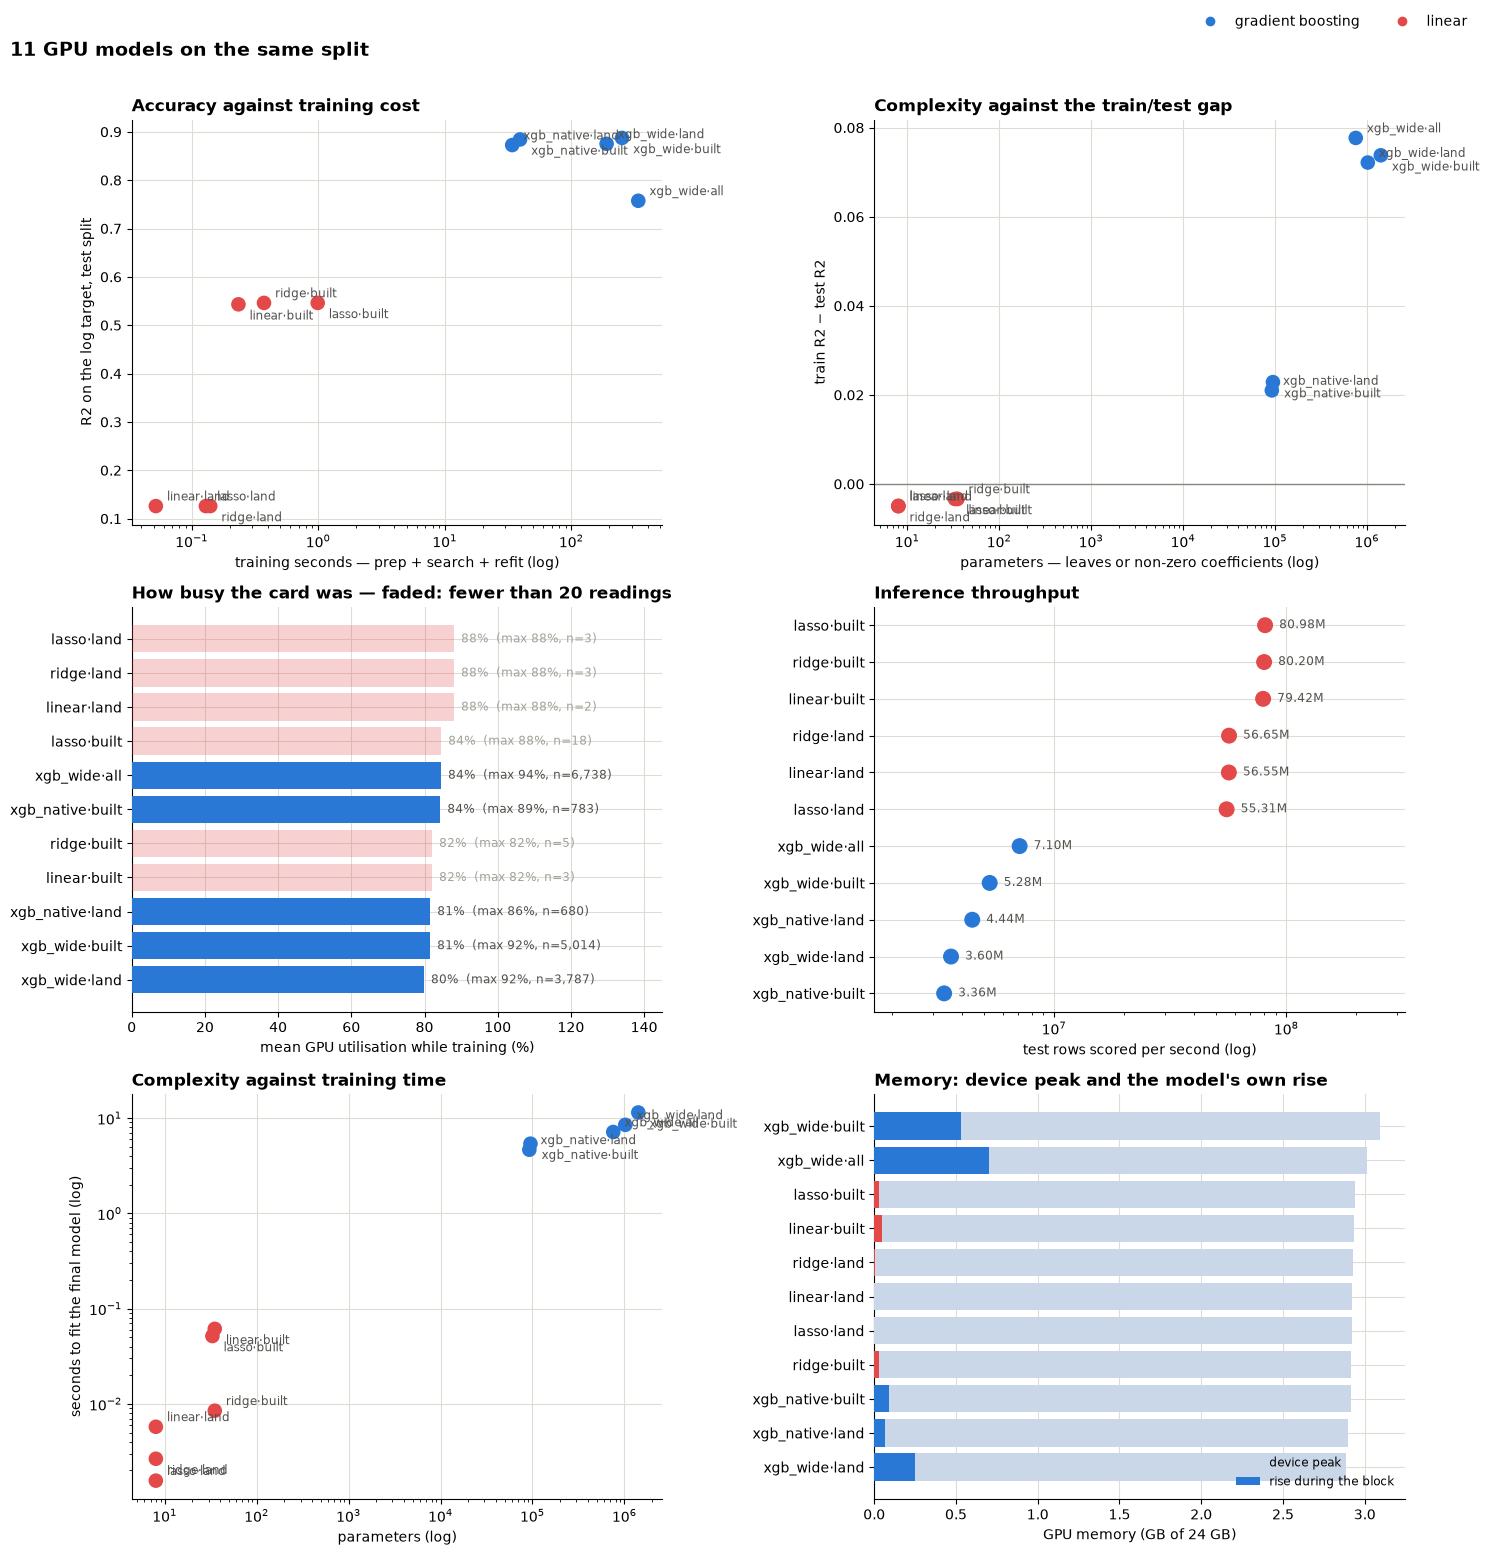

In [32]:
FAMILY_COLORS = {"gradient boosting": "#2a78d6", "linear": "#e34948"}
GRID = {"color": "#dedcd6", "linewidth": 0.8}


def annotate(ax, x, y, labels):
    """Label every point directly, alternating the offset so two models landing on
    top of each other stay readable without a legend lookup."""
    for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
        ax.annotate(label, (xi, yi), textcoords="offset points",
                    xytext=(8, 4) if i % 2 == 0 else (8, -11),
                    fontsize=8.5, color="#52514e")


fig, axes = plt.subplots(3, 2, figsize=(15, 15.5))
colors = comparison["family"].map(FAMILY_COLORS)

ax = axes[0, 0]
ax.scatter(comparison["train_total_s"], comparison["R2_log_test"], c=colors, s=90, zorder=3)
annotate(ax, comparison["train_total_s"], comparison["R2_log_test"], comparison["label"])
ax.set_xscale("log")
ax.set_xlabel("training seconds — prep + search + refit (log)")
ax.set_ylabel("R2 on the log target, test split")
ax.set_title("Accuracy against training cost", loc="left", fontweight="bold")

ax = axes[0, 1]
ax.scatter(comparison["params"], comparison["R2_gap"], c=colors, s=90, zorder=3)
annotate(ax, comparison["params"], comparison["R2_gap"], comparison["label"])
ax.axhline(0, color="#898781", linewidth=1, zorder=2)
ax.set_xscale("log")
ax.set_xlabel("parameters — leaves or non-zero coefficients (log)")
ax.set_ylabel("train R2 − test R2")
ax.set_title("Complexity against the train/test gap", loc="left", fontweight="bold")

# A fit that ends in milliseconds is polled once or twice, and that reading covers
# a driver window reaching back before the block. Those bars are faded rather than
# dropped: the honest statement is that the number exists but means little.
ax = axes[1, 0]
order = comparison.sort_values("gpu_util_mean_%")
enough = order["util_samples"] >= SAMPLED_MIN
ax.barh(order["label"], order["gpu_util_mean_%"], zorder=3,
        color=[to_rgba(FAMILY_COLORS[f], 1.0 if s else 0.25)
               for f, s in zip(order["family"], enough)])
for y, (mean, top, n) in enumerate(zip(order["gpu_util_mean_%"], order["gpu_util_max_%"],
                                       order["util_samples"])):
    ax.text(mean + 2, y, f"{mean:.0f}%  (max {top:.0f}%, n={n:,})", va="center",
            fontsize=8.5, color="#52514e" if n >= SAMPLED_MIN else "#a3a19c")
ax.set_xlim(0, 145)
ax.set_xlabel(f"mean GPU utilisation while training (%)")
ax.set_title(f"How busy the card was — faded: fewer than {SAMPLED_MIN} readings",
             loc="left", fontweight="bold")

# Dots rather than bars: the axis is logarithmic, and a bar drawn from an
# arbitrary left edge invites its length to be read as a ratio.
ax = axes[1, 1]
order = comparison.sort_values("predict_rows_per_s")
ax.scatter(order["predict_rows_per_s"], order["label"],
           color=order["family"].map(FAMILY_COLORS), s=110, zorder=3)
for y, rows in enumerate(order["predict_rows_per_s"]):
    ax.text(rows * 1.15, y, f"{rows/1e6:.2f}M", va="center", fontsize=8.5, color="#52514e")
ax.set_xscale("log")
ax.set_xlim(order["predict_rows_per_s"].min() / 2, order["predict_rows_per_s"].max() * 4)
ax.set_xlabel("test rows scored per second (log)")
ax.set_title("Inference throughput", loc="left", fontweight="bold")

ax = axes[2, 0]
ax.scatter(comparison["params"], comparison["fit_s"], c=colors, s=90, zorder=3)
annotate(ax, comparison["params"], comparison["fit_s"], comparison["label"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("parameters (log)")
ax.set_ylabel("seconds to fit the final model (log)")
ax.set_title("Complexity against training time", loc="left", fontweight="bold")

# Peak is device-wide, so the CUDA context and the frames already resident are in
# every bar. The delta above the pre-block reading is what the model itself took.
ax = axes[2, 1]
order = comparison.sort_values("mem_peak_GB")
y = np.arange(len(order))
ax.barh(y, order["mem_peak_GB"], color="#c9d7e8", zorder=3, label="device peak")
ax.barh(y, order["mem_delta_GB"], color=order["family"].map(FAMILY_COLORS), zorder=4,
        label="rise during the block")
ax.set_yticks(y, order["label"])
ax.set_xlabel(f"GPU memory (GB of {timings['built_native:fit']['mem_total_gb']:.0f} GB)")
ax.set_title("Memory: device peak and the model's own rise", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")

for ax in axes.flat:
    ax.grid(True, **GRID, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=f)
           for f, c in FAMILY_COLORS.items()]
fig.legend(handles=handles, loc="upper right", frameon=False, ncols=2,
           bbox_to_anchor=(0.99, 1.005))
fig.suptitle(f"{len(comparison)} GPU models on the same split", x=0.01, ha="left",
             fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()

#### **What the numbers say**

##### **accuracy**

On the target the models actually fit, boosting reaches `R2_log` **0.884** on built
property against **0.546** for the best linear model, and **0.873** on land against
**0.126**. In money the median listing is out by **9.9%** (built) and **13.1%** (land)
under boosting, against **31%** and **58%** under linear. The pooled first attempt —
one model over every estate type — reaches **0.757**, which is the cost of not
splitting land from built property.

##### **why the linear models collapse on land**

`city` and `district` are integer codes, and a linear model reads code 1235 as one
more than code 1234. Land price is almost entirely location — the EDA put a 12x spread
between Riyadh districts — so the one feature that matters is the one a linear model
cannot use. That is an encoding limit, not a GPU or an optimisation limit; no number of
iterations moves it. Boosting splits on the code instead of scaling it, which is how
the same eight columns give it **0.873**.

The same encoding explains the penalties doing nothing: ridge scores identically at
every alpha from `0.001` to `10`, because with 223,497 rows behind 35 coefficients
there is no variance for a penalty to remove. Lasso zeroes 2 of 35 columns on built and
none on land. These models are underfitting, and regularisation is the wrong medicine.

##### **read R2 twice**

For land, `R2_SAR` is **0.187** for boosting and **0.178** for linear, which reads as a
tie. It is not one. That metric multiplies the prediction back by an unbounded area, so
a handful of enormous plots own the squared error while the median listing sits at 13%
error against 58%. For land, trust `R2_log` and `MedAPE%`; `R2_SAR` only reports how
the largest listings went.

##### **what the regularised grid cost — built property**

|  | wide grid — depth 12, mcw 1, λ 1 | narrow grid — depth 8, mcw 50, λ 5 |
|---|---|---|
| leaves | 1,414,819 | 95,027 |
| train / test `R2_log` | 0.961 / 0.887 | 0.907 / 0.884 |
| train / test `RMSE_log` | 0.163 / 0.278 | 0.253 / 0.282 |
| test MedAPE | 8.40% | 9.91% |
| train − test `R2_log` | 0.074 | 0.023 |
| refit | 11.3 s | 5.4 s |

The constrained model gives up 1.5 points of median accuracy and 0.003 test `R2_log`.
In exchange the train/test gap falls by two thirds and the model is fifteen times
smaller. **The searches are not comparable on wall time** — 233 s bought 50 candidates,
33 s bought 5 — and per candidate the narrow grid is the more expensive of the two
(2.2 s a fit against 1.6 s), because its winner trains 1200 rounds. Only the refit
column above compares like with like.

##### **complexity against resources**

- **size buys running time, not occupancy** — fit seconds track parameter count almost
  exactly (Spearman **0.975** over all eleven models, **1.0** within the five boosters),
  but mean utilisation does not track size at all (**−0.1** within the boosters). Every
  booster pins the card at **80–83%** mean and 86–93% peak whether it holds 92k leaves
  or 1.4M. The smallest booster already saturates a 3090; a larger one simply keeps it
  saturated for longer
- **the linear timings are too short to sample** — every fit finishes in single-digit
  milliseconds while the poller reads every 50 ms, so those rows rest on two to
  seventeen readings and their 83–95% is one stale counter, not an average. They are
  faded in the utilisation chart and excluded from the utilisation correlation;
  `util_samples` in the table is there so the distinction is visible rather than
  implied
- **memory is not the constraint** — every model peaks between **2.08 and 2.40 GB** of
  the 24 GB card, under 10% of it, and most of that was already resident before
  training started. The rise attributable to the block itself is **0.000–0.240 GB**,
  and it is the one resource that scales cleanly with model size (Spearman 0.949)
- **95,027 leaves against 35 coefficients** buys **0.341** `R2_log` on built property
  (0.884 against 0.543), and costs **162x** the training time (38.9 s against 0.24 s)
  and **22x** the inference time (3.4M rows/s against 75.6M). Boosting returns
  0.023 `R2_log` per training second; the linear models return 2.3
- **more structure stopped paying inside the boosting family too** — 15x the leaves
  moved test `R2_log` by 0.003 and tripled the train/test gap. Past a point the extra
  capacity is spent on the training rows, and the table shows exactly where that point
  is

### **The consolidated table — every target, every model, every metric**

One row per trained model across all three targets, with the resources it consumed on
the left and the accuracy it bought on the right. Columns are grouped:

- **model** — the family, the rows and features it saw, and its size. `params` is
  leaves for a booster and non-zero coefficients for a linear model. They are not the
  same unit, which is the point: the two families buy accuracy with very different
  amounts of structure
- **time (s)** — the three key operations kept apart. `prep` builds and splits the
  frame on the GPU, `tune` is the hyper-parameter search, `fit` is the final refit of
  the winner on the full training split. For the linear models `prep` is shared by the
  three estimators of that target, and `tune` is the alpha sweep — zero for plain
  `LinearRegression`, which has no penalty to choose
- **speed** — `train_rows_per_s` divides the training rows by the refit time;
  `predict_rows_per_s` is the test split scored repeatedly after a warm-up. A linear
  refit finishes in single-digit milliseconds, so its throughput is a ratio of two
  small numbers and should be read as an order of magnitude, not a measurement
- **GPU** — utilisation is the duration-weighted mean over `tune` and `fit`, so the
  search dominates it where the search is what took the time. `mem_peak_GB` is
  device-wide, `mem_delta_GB` is the rise above the reading taken immediately before
  the block, and `util_samples` is how many NVML readings the row rests on
- **accuracy** — `R2_log` and `RMSE_log` score the quantity the model actually fits,
  `log1p(target)`. `MedAPE%` and the within-x% counts are ratios, so they are the same
  number in either money unit
- **error, fitted unit** — the error in what the model produces: **SAR/m² for the land
  models**, SAR for the rest, as the `target_unit` column says. This is the readable
  figure for land — a plot mispriced by so many riyals per square metre
- **error, total SAR** — the same error after multiplying land predictions back by the
  plot area, so all three targets sit on one scale. For every non-land model these are
  identical to the fitted-unit columns, because the divisor is 1. For land they are
  much larger and much less stable: area is unbounded, so a handful of enormous plots
  own the squared error

Targets: **all** is the pooled first attempt over every estate type, **built** is
everything that is not bare land, **land** predicts price per square metre.

In [33]:
COLUMN_GROUPS = (
    ("model", ("family", "train_rows", "features", "params", "unit")),
    ("time (s)", ("prep_s", "tune_s", "fit_s", "train_total_s", "predict_ms")),
    ("speed", ("train_rows_per_s", "predict_rows_per_s")),
    ("GPU", ("gpu_util_mean_%", "gpu_util_max_%", "mem_peak_GB", "mem_delta_GB",
             "mem_peak_%", "util_samples")),
    ("accuracy (test)", ("R2_log_test", "RMSE_log_test", "MedAPE%",
                         "within_10%", "within_20%")),
    ("error, fitted unit", ("target_unit", "R2_unit", "RMSE_unit", "MAE_unit")),
    ("error, total SAR", ("R2_SAR", "RMSE_SAR", "MAE_SAR")),
    ("overfit", ("R2_log_train", "RMSE_log_train", "R2_gap")),
)

ROUNDING = {"prep_s": 3, "tune_s": 3, "fit_s": 3, "train_total_s": 3, "predict_ms": 2,
            "train_rows_per_s": 0, "predict_rows_per_s": 0, "gpu_util_mean_%": 1,
            "gpu_util_max_%": 0, "mem_peak_GB": 2, "mem_delta_GB": 3, "mem_peak_%": 1,
            "R2_log_test": 3, "R2_SAR": 3, "RMSE_log_test": 3, "RMSE_SAR": 0,
            "MAE_SAR": 0, "R2_unit": 3, "RMSE_unit": 1, "MAE_unit": 1,
            "MedAPE%": 2, "within_10%": 1, "within_20%": 1,
            "R2_log_train": 3, "RMSE_log_train": 3, "R2_gap": 3}

TARGET_ORDER = {"all": 0, "built": 1, "land": 2}
MODEL_ORDER = {"xgb_wide": 0, "xgb_native": 1, "linear": 2, "ridge": 3, "lasso": 4}


def consolidated(frame: pd.DataFrame) -> pd.DataFrame:
    """The whole run as one table: models down the side, grouped metrics across."""
    ordered = frame.sort_values(
        by=["target", "model"],
        key=lambda s: s.map(TARGET_ORDER if s.name == "target" else MODEL_ORDER))
    columns = [c for _, group in COLUMN_GROUPS for c in group]
    table = ordered.set_index(["target", "model"])[columns].round(ROUNDING)
    table.columns = pd.MultiIndex.from_tuples(
        [(group, c) for group, members in COLUMN_GROUPS for c in members])
    return table


FINAL_TABLE = consolidated(comparison)
FINAL_TABLE

model                                      time (s)                                                      speed                                GPU                                                                 accuracy (test)                                             error, fitted unit                                error, total SAR                             overfit                      
                              family train_rows features   params    unit   prep_s   tune_s   fit_s train_total_s predict_ms train_rows_per_s predict_rows_per_s gpu_util_mean_% gpu_util_max_% mem_peak_GB mem_delta_GB mem_peak_% util_samples     R2_log_test RMSE_log_test MedAPE% within_10% within_20%        target_unit R2_unit   RMSE_unit   MAE_unit           R2_SAR    RMSE_SAR    MAE_SAR R2_log_train RMSE_log_train R2_gap
target model                                                                                                                                                                                                                                                                                                                                                                                                                             
all    xgb_wide    gradient boosting     373379       37   755879  leaves    0.126  330.680   7.149       337.955      22.53          52228.0          7103669.0            84.4           94.0        3.02        0.701       12.6         6738           0.757         0.601   10.95       46.9       70.7                SAR   0.165  56375037.2  1853984.1            0.165  56375037.0  1853984.0        0.835          0.493  0.078
built  xgb_wide    gradient boosting     223497       37  1414819  leaves    0.027  239.928  11.454       251.409      18.14          19513.0          5279637.0            81.5           92.0        3.09        0.531       12.9         5014           0.887         0.278    8.40       56.4       79.6                SAR   0.769   1429554.5   367644.9            0.769   1429555.0   367645.0        0.961          0.163  0.074
       xgb_native  gradient boosting     223497       36    95027  leaves    0.036   33.889   5.388        39.314      28.50          41478.0          3360455.0            84.2           89.0        2.91        0.090       12.1          783           0.884         0.282    9.91       50.4       76.5                SAR   0.771   1422592.3   397582.1            0.771   1422592.0   397582.0        0.907          0.253  0.023
       linear                 linear     223497       35       35   coefs    0.173    0.000   0.061         0.234       1.21        3645248.0         79420672.0            82.0           82.0        2.93        0.049       12.2            3           0.543         0.560   31.47       16.6       32.9                SAR   0.233   2602934.0   954813.5            0.233   2602934.0   954813.0        0.540          0.562 -0.003
       ridge                  linear     223497       35       35   coefs    0.173    0.191   0.008         0.373       1.19       26363392.0         80203132.0            82.0           82.0        2.92        0.029       12.2            5           0.546         0.558   31.11       16.9       33.2                SAR   0.253   2569918.6   950997.5            0.253   2569919.0   950998.0        0.543          0.560 -0.003
       lasso                  linear     223497       35       33   coefs    0.173    0.766   0.052         0.990       1.18        4337083.0         80982155.0            84.5           88.0        2.94        0.031       12.3           18           0.546         0.558   31.06       16.8       33.2                SAR   0.252   2571465.4   950977.2            0.252   2571465.0   950977.0        0.543          0.560 -0.003
land   xgb_wide    gradient boosting     147104       28  1021905  leaves    0.027  181.366   8.494       189.887      17.52          17318.0          3597468.0            79.8           92.0      

#### **Model complexity against resource utilisation**

The table below asks the same question three ways. `params` (leaves or coefficients)
and `features` are the two ways a model can be large; the correlations are Spearman, so
they read the ordering rather than the spacing — with eleven models and a size range
spanning five orders of magnitude, the ranks are the honest summary.

The third column repeats the first over the models whose training was slow enough to
sample. **Read the `gpu_util_mean_%` row there and nowhere else**: a linear fit ends in
five milliseconds, so its utilisation is one stale NVML reading, and across two runs of
this notebook that single row moved from +0.77 to −0.35 while every other row held. The
rest of the table is stable because seconds and bytes are measured directly rather than
sampled.

`per-second` and `per-parameter` returns are the same numbers from the other side: what
a model bought per unit of what it spent.

In [34]:
RESOURCE_COLS = ("fit_s", "tune_s", "train_total_s", "train_rows_per_s",
                 "predict_rows_per_s", "gpu_util_mean_%", "mem_delta_GB",
                 "R2_log_test", "R2_gap")


def complexity_correlations(frame: pd.DataFrame) -> pd.DataFrame:
    """Spearman rank correlation of each resource metric against model size.

    The last column repeats the first over the models whose training blocks ran
    long enough to be polled properly. Utilisation on a five-millisecond fit is one
    stale NVML reading, and including those rows makes the utilisation correlation
    move between runs; the restricted column is the one to read for that row.
    """
    sampled = frame[frame["util_samples"] >= SAMPLED_MIN]
    return pd.DataFrame(
        {"vs params": [frame[c].corr(frame["params"], method="spearman")
                       for c in RESOURCE_COLS],
         "vs features": [frame[c].corr(frame["features"], method="spearman")
                         for c in RESOURCE_COLS],
         f"vs params, {len(sampled)} sampled": [
             sampled[c].corr(sampled["params"], method="spearman")
             for c in RESOURCE_COLS]},
        index=list(RESOURCE_COLS)).round(3)


def efficiency(frame: pd.DataFrame) -> pd.DataFrame:
    """What each model returned per unit of the resource it spent."""
    out = frame[["target", "model", "params", "train_total_s", "R2_log_test"]].copy()
    out["R2_per_train_s"] = out["R2_log_test"] / out["train_total_s"]
    out["params_per_R2_point"] = out["params"] / (out["R2_log_test"] * 100)
    busy_seconds = (frame["tune_s"] + frame["fit_s"]) * frame["gpu_util_mean_%"] / 100
    out["gpu_seconds_per_R2_point"] = busy_seconds / (out["R2_log_test"] * 100)
    return out.set_index(["target", "model"]).round(
        {"R2_log_test": 3, "train_total_s": 2, "R2_per_train_s": 4,
         "params_per_R2_point": 1, "gpu_seconds_per_R2_point": 3})


sampled = comparison[comparison["util_samples"] >= SAMPLED_MIN]["label"].tolist()
print("Spearman rank correlation — model size against what it costs")
print(f"well-sampled models ({SAMPLED_MIN}+ NVML readings): {', '.join(sampled)}\n")
print(complexity_correlations(comparison))
print("\n\nReturn per unit of resource\n")
print(efficiency(comparison))

Spearman rank correlation — model size against what it costs
well-sampled models (20+ NVML readings): xgb_wide·all, xgb_wide·built, xgb_wide·land, xgb_native·built, xgb_native·land

                    vs params  vs features  vs params, 5 sampled
fit_s                   0.975        0.692                   1.0
tune_s                  0.869        0.659                   0.7
train_total_s           0.933        0.744                   0.7
train_rows_per_s       -0.897       -0.447                  -0.5
predict_rows_per_s     -0.621       -0.118                   0.3
gpu_util_mean_%        -0.842       -0.391                  -0.5
mem_delta_GB            0.949        0.746                   0.7
R2_log_test             0.929        0.640                   0.5
R2_gap                  0.961        0.744                   0.7


Return per unit of resource

                    params  train_total_s  R2_log_test  R2_per_train_s  params_per_R2_point  gpu_seconds_per_R2_point
target model       